# long-short-portfolio

On the first trading day of every month, rebalance portfolio to given percentages.  One of the positions is a short position.

In [1]:
import datetime

import matplotlib.pyplot as plt
import pandas as pd

import pinkfish as pf

# Format price data.
pd.options.display.float_format = '{:0.2f}'.format

%matplotlib inline

In [2]:
# Set size of inline plots.
'''note: rcParams can't be in same cell as import matplotlib
   or %matplotlib inline
   
   %matplotlib notebook: will lead to interactive plots embedded within
   the notebook, you can zoom and resize the figure
   
   %matplotlib inline: only draw static images in the notebook
'''
plt.rcParams["figure.figsize"] = (10, 7)

Define Portfolios

Note: By using an underscore, we can use a symbol multiple times in a portfolio under a different name.  This is useful when you want to have a short and long position at the same time.

In [3]:
portfolio_option = {'SPY': 0.50, 'TLT': 0.30, 'GLD': 0.10, 'TLT_SHRT': 0.10}

directions = {'SPY': pf.Direction.LONG, 'TLT': pf.Direction.LONG,
              'GLD': pf.Direction.LONG, 'TLT_SHRT' : pf.Direction.SHORT}

Some global data

In [4]:
symbols = list(portfolio_option.keys())
capital = 10000
start = datetime.datetime(1900, 1, 1)
end = datetime.datetime.now()

In [5]:
options = {
    'use_adj' : True,
    'use_cache' : True,
}
options

{'use_adj': True, 'use_cache': True}

In [6]:
# Fetch timeseries
portfolio = pf.Portfolio()
ts = portfolio.fetch_timeseries(symbols, start, end, fields=['close'],
                                use_cache=options['use_cache'], use_adj=options['use_adj'])
# Add calendar columns
ts = portfolio.calendar(ts)

# Finalize timeseries
ts, start = portfolio.finalize_timeseries(ts, start)

# Init trade logs
portfolio.init_trade_logs(ts)

In [7]:
pf.TradeLog.cash = capital

# Trading algorithm
for i, row in enumerate(ts.itertuples()):

    end_flag = pf.is_last_row(ts, i)
    
    # Rebalance on the first trading day of each month
    if row.first_dotm or end_flag:

        portfolio.print_holdings(row)
        
        # If last row, then zero out all weights.  Otherwise use portfolio_option weights.
        weights = portfolio_option if not end_flag else pf.set_dict_values(portfolio_option, 0)
        
        # Adjust weights of all symbols in portfolio
        portfolio.adjust_percents(row, weights, field='close', directions=directions)

    # Record daily balance.
    portfolio.record_daily_balance(row)

2004-12-01 GLD:  0 SPY:  0 TLT_SHRT:  0 TLT:  0 cash: 10,000.00 total: 10,000.00
2005-01-03 GLD: 22 SPY: 62 TLT_SHRT: 23 TLT: 69 cash:    75.79 total: 10,076.49
2005-02-01 GLD: 23 SPY: 61 TLT_SHRT: 22 TLT: 68 cash:   199.99 total: 10,062.71
2005-03-01 GLD: 23 SPY: 62 TLT_SHRT: 22 TLT: 66 cash:   210.81 total: 10,158.75
2005-04-01 GLD: 23 SPY: 61 TLT_SHRT: 22 TLT: 67 cash:   247.81 total: 10,005.39
2005-05-02 GLD: 23 SPY: 62 TLT_SHRT: 22 TLT: 66 cash:   213.06 total: 10,037.17
2005-06-01 GLD: 23 SPY: 63 TLT_SHRT: 21 TLT: 64 cash:   266.45 total: 10,270.14
2005-07-01 GLD: 24 SPY: 62 TLT_SHRT: 21 TLT: 63 cash:   355.37 total: 10,271.69
2005-08-01 GLD: 24 SPY: 63 TLT_SHRT: 21 TLT: 63 cash:   273.86 total: 10,406.91
2005-09-01 GLD: 24 SPY: 61 TLT_SHRT: 22 TLT: 66 cash:   253.60 total: 10,452.08
2005-10-03 GLD: 23 SPY: 62 TLT_SHRT: 21 TLT: 64 cash:   349.27 total: 10,450.00
2005-11-01 GLD: 22 SPY: 62 TLT_SHRT: 22 TLT: 66 cash:   254.71 total: 10,312.28
2005-12-01 GLD: 22 SPY: 62 TLT_SHRT: 22

In [8]:
# Get logs
rlog, tlog, dbal = portfolio.get_logs()

In [9]:
rlog.head(10)

,date,seq_num,price,shares,entry_exit,direction,symbol
0,2004-12-01,0,45.38,22,entry,LONG,GLD
0,2004-12-01,1,42.92,23,entry,SHRT,TLT_SHRT
0,2004-12-01,2,42.92,69,entry,LONG,TLT
0,2004-12-01,3,80.28,62,entry,LONG,SPY
1,2005-01-03,4,44.22,1,exit,LONG,TLT
1,2005-01-03,5,81.38,1,exit,LONG,SPY
1,2005-01-03,6,44.22,1,exit,SHRT,TLT_SHRT
1,2005-01-03,7,43.02,1,entry,LONG,GLD
2,2005-02-01,8,45.63,2,exit,LONG,TLT
2,2005-02-01,9,80.44,1,entry,LONG,SPY


In [10]:
tlog.tail(100)

,entry_date,entry_price,exit_date,exit_price,pl_points,pl_cash,qty,cumul_total,direction,symbol
81,2019-07-01,108.21,2026-06-08,84.62,23.59,23.59,1,30783.36,SHRT,TLT_SHRT
144,2019-07-01,108.21,2026-06-08,84.62,-23.59,-94.35,4,30689.01,LONG,TLT
131,2019-08-01,266.89,2026-06-08,739.22,472.33,472.33,1,31161.34,LONG,SPY
132,2019-09-03,263.18,2026-06-08,739.22,476.04,952.07,2,32113.41,LONG,SPY
70,2019-10-01,139.63,2025-01-02,245.42,105.79,105.79,1,32219.20,LONG,GLD
...,...,...,...,...,...,...,...,...,...,...
106,2026-04-01,85.61,2026-06-08,84.62,0.99,4.93,5,42032.45,SHRT,TLT_SHRT
107,2026-05-01,85.27,2026-06-08,84.62,0.65,0.65,1,42033.10,SHRT,TLT_SHRT
187,2026-05-01,85.27,2026-06-08,84.62,-0.65,-5.89,9,42027.21,LONG,TLT
86,2026-06-01,411.26,2026-06-08,397.27,-13.99,-13.99,1,42013.22,LONG,GLD


In [11]:
dbal.tail()

,high,low,close,shares,cash,leverage,state
date,,,,,,,
2026-06-02,56719.62,56719.62,56719.62,306,64.97,1.00,-
2026-06-03,56426.19,56426.19,56426.19,306,64.97,1.00,-
2026-06-04,56598.85,56598.85,56598.85,306,64.97,1.00,-
2026-06-05,55634.35,55634.35,55634.35,306,64.97,1.00,-
2026-06-08,52009.82,52009.82,52009.82,0,52009.82,1.00,X


In [12]:
stats = pf.stats(ts, tlog, dbal, capital)
pf.print_full(stats)

start                                                   2004-11-18
end                                                     2026-06-08
beginning_balance                                            10000
ending_balance                                            52009.82
total_net_profit                                          42009.82
gross_profit                                              47726.36
gross_loss                                                -5716.54
profit_factor                                                 8.35
return_on_initial_capital                                   420.10
annual_return_rate                                            7.95
trading_period                           21 years 6 months 21 days
pct_time_in_market                                           99.85
margin                                                           1
avg_leverage                                                  1.00
max_leverage                                                  

,cumul_total,weight,pct_cumul_total,relative_performance
GLD,"$6,423.64",0.10,0.15,1.53
SPY,"$34,171.75",0.50,0.81,1.63
TLT_SHRT,-$657.12,0.10,-0.02,-0.16
TLT,"$2,071.55",0.30,0.05,0.16
TOTAL,"$42,009.82",1.00,1.00,1.00


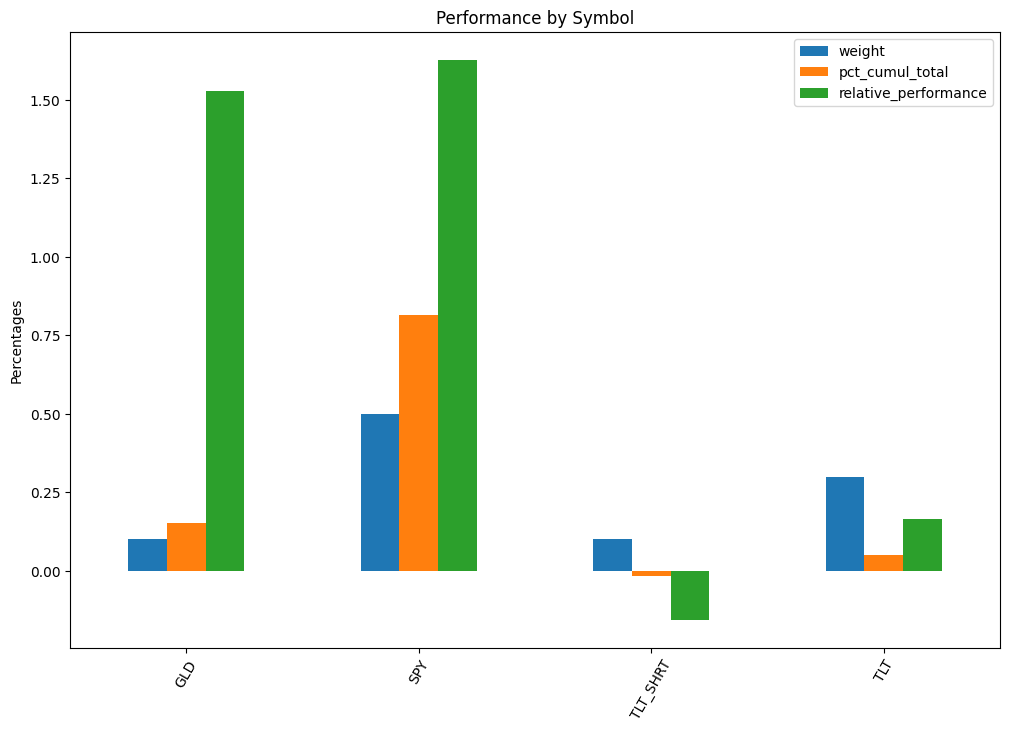

In [13]:
totals = portfolio.performance_per_symbol(portfolio_option)
totals

In [14]:
benchmark = pf.Benchmark('SPY', capital, start, end, use_adj=True)
benchmark.run()

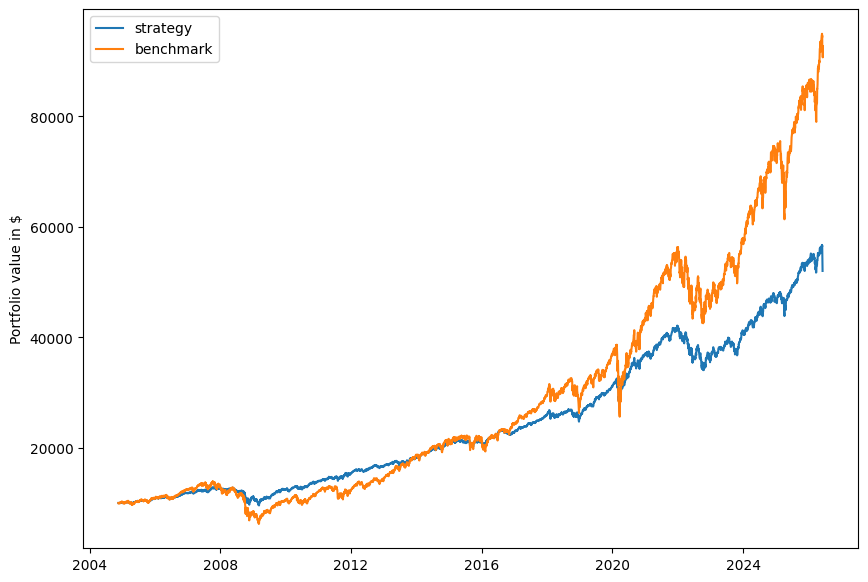

In [15]:
pf.plot_equity_curve(dbal, benchmark=benchmark.dbal)

In [16]:
df = pf.summary(stats, benchmark.stats, metrics=pf.currency_metrics)
df

,strategy,benchmark
beginning_balance,"$10,000.00","$10,000.00"
ending_balance,"$52,009.82","$92,724.92"
total_net_profit,"$42,009.82","$82,724.92"
gross_profit,"$47,726.36","$82,724.92"
gross_loss,"-$5,716.54",$0.00


,strategy,benchmark
annual_return_rate,7.95,10.88
max_closed_out_drawdown,-25.71,-55.16
annualized_return_over_max_drawdown,0.31,0.20
best_month,14.11,23.60
worst_month,-15.76,-30.98
sharpe_ratio,0.88,0.64
sortino_ratio,1.11,0.78
monthly_std,2.34,4.48
annual_std,8.28,16.04


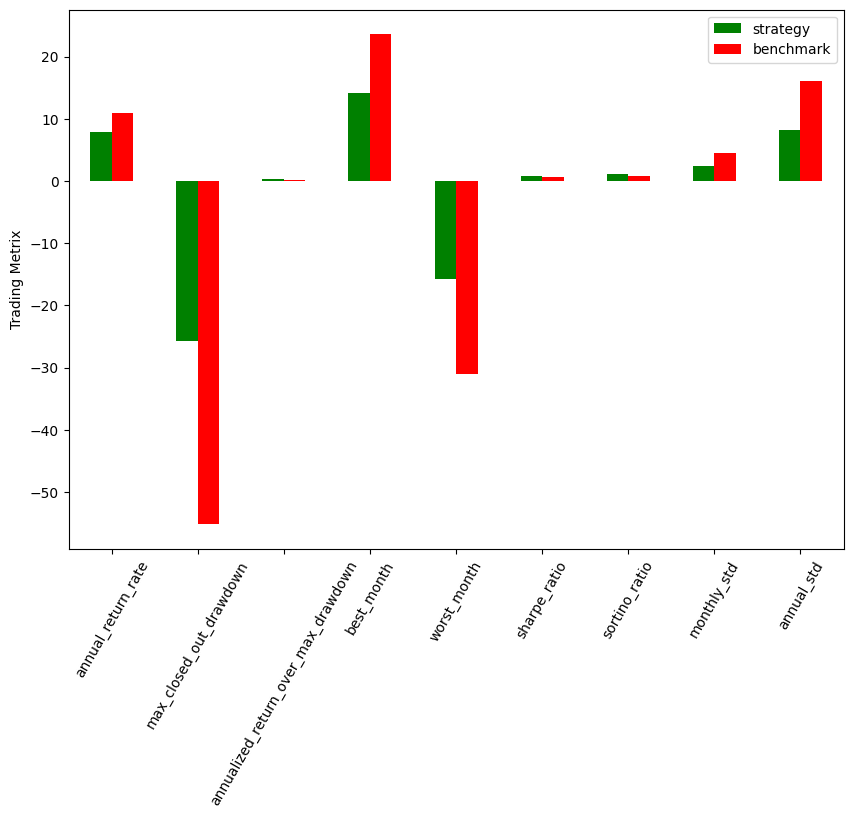

In [17]:
df = pf.plot_bar_graph(stats, benchmark.stats)
df